# Teton Classifier Notebook

Random Forest Classifier for the Teton Range, based off of Yang et al. (2023)

## Imports and initializations

In [1]:
import os
import ee
import geemap
import pandas as pd


In [2]:
ee.Authenticate()

True

In [3]:
import os
import ee
import geemap
import pandas as pd

EE_PROJECT = "teton-classifier"
# Alpine-ish mask threshold for this first pass. Adjust after inspecting the map.
ALPINE_MIN_ELEV_M = 2200
YEAR = 2023
START_DATE = f"{YEAR}-06-15"
END_DATE = f"{YEAR}-09-20"
SCALE = 10
SEED = 42

if EE_PROJECT:
    ee.Initialize(project=EE_PROJECT)
else:
    ee.Initialize()
print("Earth Engine initialized.")

Earth Engine initialized.


## Map, draw study boundary or use preset box


In [4]:
Map = geemap.Map(center=[43.75, -110.75], zoom=10)
aoi = ee.Geometry.Rectangle([-111.05, 43.35, -110.45, 44.05])
Map.addLayer(aoi, {"color": "yellow"}, "AOI")
Map

Map(center=[43.75, -110.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprigh…

## Gather data

In [5]:
features = [
    # Sentinel-2 reflectance
    "B2", "B3", "B4",      # blue, green, red
    "B8",                 # near infrared
    "B11", "B12",         # shortwave infrared

    # Spectral indices
    "NDVI",               # vegetation greenness
    "NDWI",               # water / wetness
    "NDSI",               # snow / ice
    "BSI",                # bare soil / rock tendency

    # Terrain
    "elevation",
    "slope",
    "aspect"
]

### Import s2 images for the summer, excluding very cloudy images

In [22]:
s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi)
    .filterDate(START_DATE, END_DATE)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 60))
)

## Import s1

In [59]:
s1 = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filterBounds(aoi)
    .filterDate(START_DATE, END_DATE)
    .filter(ee.Filter.eq("instrumentMode", "IW"))
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
    .select(["VV", "VH"])
    .median()
    .clip(aoi)
)

### Mask out clouds

In [7]:
def mask_s2_clouds(image):
    qa = image.select("QA60")


    # Identifying relevant bits in the QA60 band for cloud and cirrus detection
    cloud_bit = 1 << 10
    cirrus_bit = 1 << 11

    mask = (
        qa.bitwiseAnd(cloud_bit).eq(0)
        .And(qa.bitwiseAnd(cirrus_bit).eq(0))
    )

    return image.updateMask(mask).divide(10000)

# Apply mask
s2_masked = s2.map(mask_s2_clouds)
# Generate median composite
s2_composite = s2_masked.median()

### Map composite

In [23]:
# Generate median composite
s2_composite = s2_masked.median().clip(aoi)

Map.addLayer(
    s2_composite,
    {
        "bands": ["B4", "B3", "B2"],
        "min": 0.02,
        "max": 0.3
    },
    "Sentinel-2 summer composite"
)

bbox_outline = ee.Image().byte().paint(
    featureCollection=ee.FeatureCollection([ee.Feature(aoi)]),
    color=1,
    width=4
)

Map.addLayer(
    bbox_outline,
    {"palette": ["yellow"]},
    "Bounding box"
)

Map

Map(bottom=48141.0, center=[43.64203827340191, -110.0445556640625], controls=(WidgetControl(options=['position…

### Calculate NDVI index

In [24]:
ndvi = s2_composite.normalizedDifference(["B8", "B4"]).rename("NDVI")

Map.addLayer(
    ndvi,
    {
        "min": -0.2,
        "max": 0.8,
        "palette": ["brown", "white", "green"]
    },
    "NDVI"
)
Map.addLayer(
    bbox_outline,
    {"palette": ["yellow"]},
    "Bounding box"
)
Map

Map(bottom=48141.0, center=[43.64203827340191, -110.0445556640625], controls=(WidgetControl(options=['position…

### NDWI

In [25]:
ndwi = s2_composite.normalizedDifference(["B3", "B8"]).rename("NDWI")
Map.addLayer(
    ndwi,
    {
        "min": -0.5,
        "max": 0.5,
        "palette": ["brown", "white", "blue"]
    },
    "NDWI"
)
Map.addLayer(
    bbox_outline,
    {"palette": ["yellow"]},
    "Bounding box"
)
Map

Map(bottom=48141.0, center=[43.64203827340191, -110.0445556640625], controls=(WidgetControl(options=['position…

### NDSI (Snow index)

In [14]:
ndsi = s2_composite.normalizedDifference(["B3", "B11"]).rename("NDSI")

Map.addLayer(
    ndsi,
    {
        "min": -0.5,
        "max": 0.8,
        "palette": ["gray", "white", "cyan"]
    },
    "NDSI"
)

Map.addLayer(
    bbox_outline,
    {"palette": ["yellow"]},
    "Bounding box"
)
Map

Map(bottom=95723.0, center=[43.898881944430414, -110.91659545898439], controls=(WidgetControl(options=['positi…

### BSI (Bare Soil Index)

In [15]:
bsi = s2_composite.expression(
    "((SWIR + RED) - (NIR + BLUE)) / ((SWIR + RED) + (NIR + BLUE))",
    {
        "SWIR": s2_composite.select("B11"),
        "RED": s2_composite.select("B4"),
        "NIR": s2_composite.select("B8"),
        "BLUE": s2_composite.select("B2"),
    }
).rename("BSI")

Map.addLayer(
    bsi,
    {
        "min": -0.5,
        "max": 0.5,
        "palette": ["darkgreen", "white", "sienna"]
    },
    "BSI"
)

Map.addLayer(
    bbox_outline,
    {"palette": ["yellow"]},
    "Bounding box"
)
Map


Map(bottom=95845.0, center=[43.77803507867669, -110.83831787109376], controls=(WidgetControl(options=['positio…

### Terrain indicators (slope, elevation, aspect)

In [17]:
terrain = ee.Algorithms.Terrain(
    ee.Image("NASA/NASADEM_HGT/001").select("elevation")
).clip(aoi)

elevation = terrain.select("elevation")
slope = terrain.select("slope")
aspect = terrain.select("aspect")

In [20]:
# To display:

Map.addLayer(
    elevation,
    {
        "min": 1800,
        "max": 4200,
        "palette": ["blue", "white", "red"]
    },
    "Elevation",
    opacity=0.5
)

Map.addLayer(
    slope,
    {
        "min": 0,
        "max": 60,
        "palette": ["white", "orange", "red"]
    },
    "Slope",
    opacity=0.5
)

# Map.addLayer(
#     aspect,
#     {
#         "min": 0,
#         "max": 360,
#         "palette": ["blue", "green", "yellow", "red", "blue"]
#     },
#     "Aspect"
# )

Map

Map(bottom=191485.0, center=[43.73091784974365, -110.79025268554689], controls=(WidgetControl(options=['positi…

### Build training composite image

In [65]:
feature_image = s2_composite.select([
    "B2", "B3", "B4", "B8", "B11", "B12"
]).addBands([
    ndvi,
    ndwi,
    ndsi,
    bsi,
    elevation,
    slope,
    aspect
])

feature_image = feature_image.addBands(s1)

# Check
feature_image.bandNames().getInfo()

['B2',
 'B3',
 'B4',
 'B8',
 'B11',
 'B12',
 'NDVI',
 'NDWI',
 'NDSI',
 'BSI',
 'elevation',
 'slope',
 'aspect',
 'VV',
 'VH']

## Build Model

### Build truth values with Dynamic World

In [66]:
dw = (
    ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
    .filterBounds(aoi)
    .filterDate(START_DATE, END_DATE)
)

dw_classes = {
    0: "water",
    1: "trees",
    2: "grass",
    3: "flooded_vegetation",
    4: "crops",
    5: "shrub_and_scrub",
    6: "built",
    7: "bare",
    8: "snow_and_ice",
}

#To remove noise: these are the classes we care about, at least for alpine classification: 
# water, trees, grass, shrub/scrub, bare, snow/ice. Ignoring flooded vegetation, crops, and built areas \

keep_classes = [0, 1, 2, 5, 7, 8]

label_image = dw.select("label").mode().clip(aoi).rename("class")
class_mask = label_image.remap(
    keep_classes,
    [1, 1, 1, 1, 1, 1],
    0
).eq(1)

label_image = label_image.updateMask(class_mask)

training_image = feature_image.addBands(label_image)

#sample training points

samples = training_image.stratifiedSample(
    numPoints=200,
    classBand="class",
    region=aoi,
    scale=10,
    seed=42,
    geometries=True
)

# Check the number of samples and their class distribution
samples.size().getInfo()
samples.aggregate_histogram("class").getInfo()

samples = samples.randomColumn("random", seed=7)
training_samples = samples.filter(ee.Filter.lt("random", 0.7))
validation_samples = samples.filter(ee.Filter.gte("random", 0.7))

## Train RF Model

In [67]:
feature_names = feature_image.bandNames()

rf = ee.Classifier.smileRandomForest(
    numberOfTrees=100,
    seed=42
).train(
    features=training_samples,
    classProperty="class",
    inputProperties=feature_names
)

## And apply to each pixel?

classified = feature_image.classify(rf)

### Plot classification results

In [71]:
class_palette = [
    "419bdf",  # 0 water: medium blue
    "397d49",  # 1 trees: dark green
    "88b053",  # 2 grass: light olive green
    "7a87c6",  # 3 flooded vegetation: muted blue-purple
    "e49635",  # 4 crops: orange
    "dfc35a",  # 5 shrub/scrub: yellow-tan
    "c4281b",  # 6 built: red
    "a59b8f",  # 7 bare: gray-beige
    "b39fe1",  # 8 snow/ice: light purple
]

# Resets map layers!

Map = geemap.Map(center=[43.75, -110.75], zoom=10)
Map.addLayer(aoi, {"color": "yellow"}, "AOI")
Map.addLayer(s2_composite, {"bands": ["B4", "B3", "B2"], "min": 0.02, "max": 0.3}, "Sentinel-2 true color")
Map.addLayer(feature_image, {"bands": ["VH"], "min": -25, "max": 0}, "Sentinel-1 true color")
Map.addLayer(terrain.select("elevation"), {"min": 1800, "max": 4200, "palette": ["2166ac", "f7f7f7", "b2182b"]}, "Elevation")
Map.addLayer(label_image, {"min": 0, "max": 8, "palette": class_palette}, "Dynamic World weak labels")
Map.addLayer(classified, {"min": 0, "max": 8, "palette": class_palette}, "Random Forest classification")
Map.addLayer(training_samples, {"color": "white"}, "Training points", False)
Map.addLayer(validation_samples, {"color": "black"}, "Validation points", False)
Map.add_tile_layer(
    url="https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}",
    name="Esri World Topo 50%",
    attribution="Esri, USGS, NOAA",
    opacity=0.5,
)
Map.addLayerControl()
Map

Map(center=[43.75, -110.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprigh…

In [58]:
import requests

dw_vis = {
    "min": 0,
    "max": 8,
    "palette": class_palette,
}

url = label_image.clip(aoi).getThumbURL({
    "region": aoi,
    "dimensions": 2000,
    "format": "png",
    **dw_vis,
})

response = requests.get(url)

with open("teton_dynamic_world_labels.png", "wb") as f:
    f.write(response.content)

print("Saved teton_dynamic_world_labels.png")

Saved teton_dynamic_world_labels.png


### Print accuracy

In [68]:
validated = validation_samples.classify(rf)

confusion_matrix = validated.errorMatrix("class", "classification")
matrix = confusion_matrix.getInfo()

print(confusion_matrix.getInfo())
print("Accuracy:", confusion_matrix.accuracy().getInfo())
print("Kappa:", confusion_matrix.kappa().getInfo())

print(samples.aggregate_histogram("class").getInfo())

[[55, 1, 0, 0, 0, 0, 0, 0, 2], [0, 54, 6, 0, 0, 4, 0, 0, 0], [0, 0, 54, 0, 0, 6, 0, 1, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 13, 0, 0, 34, 0, 6, 2], [0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 3, 0, 0, 3, 0, 34, 16], [1, 0, 0, 0, 0, 1, 0, 9, 48]]
Accuracy: 0.7903682719546742
Kappa: 0.748228966873247
{'0': 200, '1': 200, '2': 200, '5': 200, '7': 200, '8': 200}


### Plot confusion matrix

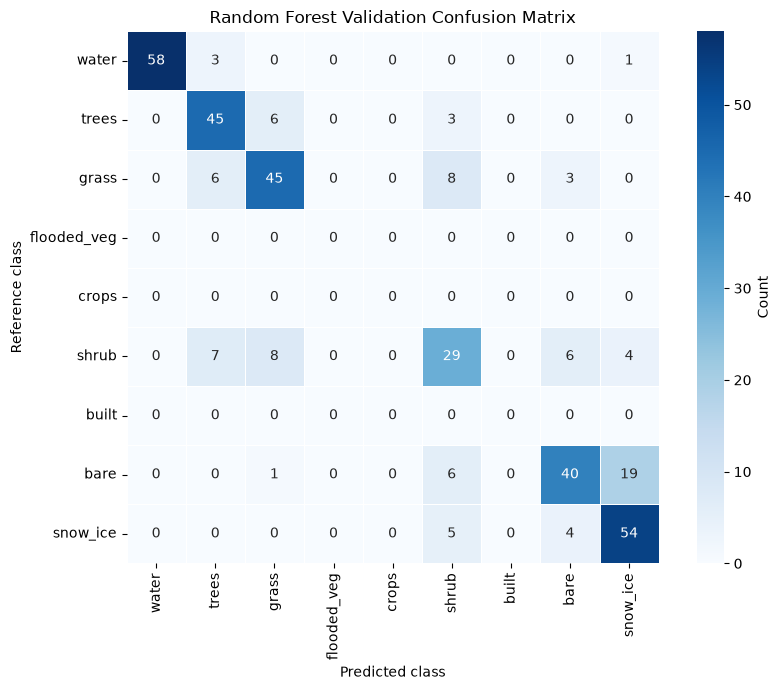

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

class_names = [
    "water",
    "trees",
    "grass",
    "flooded_veg",
    "crops",
    "shrub",
    "built",
    "bare",
    "snow_ice",
]

matrix_df = pd.DataFrame(
    matrix,
    index=class_names,
    columns=class_names
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    matrix_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Count"}
)

plt.xlabel("Predicted class")
plt.ylabel("Reference class")
plt.title("Random Forest Validation Confusion Matrix")
plt.tight_layout()
plt.show()